# BIDS: Brain Imaging Data Structure

## Benefícios práticos no MNE

### Sem BIDS:
```python
# Carregar manualmente
raw1 = mne.io.read_raw_edf("dados/paciente1_dia1.edf")
raw2 = mne.io.read_raw_edf("dados/paciente1_dia2.edf")  
raw3 = mne.io.read_raw_edf("dados/paciente2_dia1.edf")

# Carregar eventos separadamente
eventos1 = pd.read_csv("eventos/p1_d1.csv")
eventos2 = pd.read_csv("eventos/p1_d2.csv")

# Isso gera muito trabalho manual
```

### Com BIDS:
```python
# Loop automático
from mne_bids import get_entity_vals, read_raw_bids

subjects = get_entity_vals(bids_root, 'subject')

for subject in subjects:
    sessions = get_entity_vals(bids_root, 'session', subject=subject)
    
    for session in sessions:
        bids_path = BIDSPath(
            subject=subject,
            session=session,
            task='motor',
            root=bids_root
        )
        
        raw = read_raw_bids(bids_path)
        # Dados + eventos carregados automaticamente.
        
        # Processar...
```

## Validação BIDS

```python
from mne_bids import print_dir_tree
from bids_validator import BIDSValidator

# Ver estrutura
print_dir_tree('/caminho/bids')

# Validar se está correto
validator = BIDSValidator()
is_valid = validator.is_bids('/caminho/bids')
print(f"Dataset válido? {is_valid}")
```

## Resumo

| Aspecto | Descrição |
|---------|-----------|
| **O que é** | Padrão de organização para dados cerebrais |
| **Origem** | 2016, comunidade de neurociência |
| **Por quê** | Padronizar, compartilhar, automatizar |
| **No MNE** | `mne-bids` para ler/escrever |
| **Vantagem** | Análise automática de múltiplos sujeitos |

**Em linhas gerais:** O BIDS transforma o caos em ordem, permitindo que você e outros pesquisadores entendam e processem dados cerebrais de forma padronizada e eficiente.

## Usando dados BIDS 

É, de forma resumida, um *package* (coleção de funções) que permite ler e escrever *BIDS data*. Podemos literalmente converter um *dataset* para o formato BIDS.

Existe uma seção de documentação própria [MNE BIDS](https://mne.tools/mne-bids/stable/index.html).

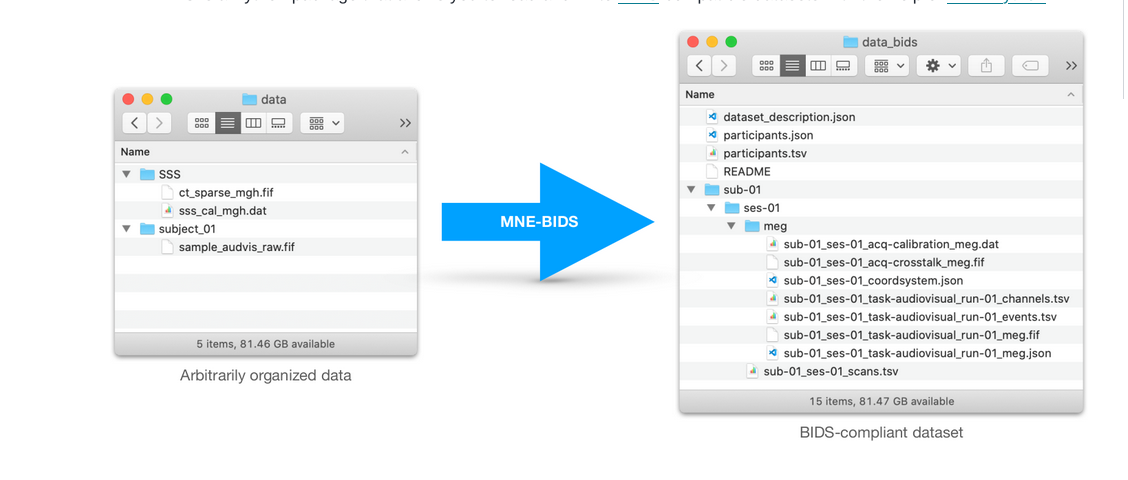

In [ ]:
%pip install PyQt5

In [ ]:
import matplotlib
import pathlib

import mne
import mne_bids

matplotlib.use('Qt5Agg')

print(mne_bids.__version__)

## Leia os dados de entrada que desejamos converter em BIDS.

In [ ]:
sample_data_dir = '/Users/Renan/Pictures/Universidade/8periodo/EEG-NeuroComp/mne-eeg-python-introducao/MNE-sample-data' # Importante mudar o caminho onde está baixado na sua máquina
# Caso não tenha baixado: 
# sample_data_dir = mne.datasets.sample.data_path() 

sample_data_dir = pathlib.Path(sample_data_dir) # O operador '/' só funciona com objetos pathlib.Path, ele habilita o operador '/' para juntar pastas de forma intuitiva.

raw_path = sample_data_dir / 'MEG' / 'sample' / 'sample_audvis_raw.fif'
raw = mne.io.read_raw(raw_path)

events = mne.find_events(raw)
event_id = {
    'Auditory/Left': 1,
    'Auditory/Right': 2,
    'Visual/Left': 3,
    'Visual/Right': 4,
    'Smiley': 5,
    'Button': 32
}

## Escrevendo dados no formato BIDS

Precisamos especificar a frequência da linha

In [ ]:
raw.info['line_freq'] = 60 

### O que é `line_freq`?

É um campo do `raw.info` que diz:

> **Qual é a frequência da rede elétrica que contamina o sinal EEG/MEG?**

No mundo real, captamos ruídos constantes da rede elétrica:

- **60 Hz** → Américas.
- **50 Hz** → Europa, Ásia e Austrália.

Esse ruído aparece como um **pico forte no espectro** e precisa ser filtrado.

O MNE usa essa informação para:

- Anotar o ruído na estrutura dos dados.
- Usar no filtro notch (`mne.filter.notch_filter`).
- Avisar ferramentas downstream.  
- Registrar corretamente nos METADADOS do BIDS.

### E como isso aparece?

Depois de definir:

```python
raw.info['line_freq'] = 60
```

O MNE-BIDS cria um arquivo JSON assim:

```json
{
  "PowerLineFrequency": 60,
  ...
}
```

---
### Definindo Informações do Participante (`subject_info`)
O MNE armazena dados demográficos em um dicionário chamado `subject_info`. Ao converter para BIDS, esses dados preencherão automaticamente o arquivo `participants.tsv`.

**Convenções de códigos do MNE:**
* **birthday**: Deve ser um objeto `datetime.date` (Ano, Mês, Dia).
* **sex**:
    * `0`: Desconhecido
    * `1`: Masculino
    * `2`: Feminino
* **hand** (Lateralidade):
    * `1`: Destro
    * `2`: Canhoto
    * `3`: Ambidestro
---

In [ ]:
from datetime import date # Necessário para o campo 'birthday'

# Definindo dados do participante através de um dicionário com informações demográficas
subject_info = {
    "first_name": "Maria",
    "middle_name": "Heloysa",
    # Obs: Como os dados de exemplo do MNE são antigos (aprox. 2002), usamos uma data de nascimento compatível para não gerar idades negativas ou irreais.
    "birthday":date(1996,1,30), 
    "sex": 2, # 1=Masculino, 2=Feminino
    "hand": 1  # 1=Destro, 2=Canhoto
    
}

# raw.info retorna dicinário aninhado
raw.info['subject_info'] = subject_info # substituindo meu dicionário com dados dos participantes

raw.info

Agora, de fato, gravamos os dados

In [ ]:
# Define a pasta raiz onde o dataset BIDS será criado.
# Se os diretórios não existirem, o mne-bids criará automaticamente.
out_path = pathlib.Path('out_data/sample_BIDS') 


# Criamos a estrutura BIDS descrita, mas ainda não gravada no disco.
# Isso define o caminho padronizado que o BIDS exige. Esses parâmetros são chamados 'Entidades BIDS'.
bids_path = mne_bids.BIDSPath(
    subject='01',        # Identificador do participante (sub-01).
    session='01',        # Sessão (ses-01). Opicional, útil para visitas em dias distintos. 
    task='audiovisual',  # Nome da tarefa experimental (task-audiovisual). Obrigatório.
    run='01',            # Número da execução (run-01). Útil se a tarefa foi repetida.
    root=out_path        # Onde a pasta raiz será criada.
)


# Grava os dados, metadados e eventos no disco.
mne_bids.write_raw_bids(
    raw,                 # Objeto Raw do MNE (seu EEG/MEG carregado)
    bids_path=bids_path, # Caminho e metadados definidos acima
    events=events,       # Matriz Nx3 com a informação dos eventos, opcional, mas, se você não especificar, nenhum evento será registrado (perda de informação)
    event_id=event_id,   # Dicionário que mapeia nome → ID do evento
    overwrite=True       # Permite sobrescrever se a pasta já existir
)

# Em versões antigas do MNE-BIDS, o argumento para passar os eventos chamava-se events_data. Nas versões atuais, ele foi renomeado para events. 
# Se você encontrar tutoriais antigos, atente-se a esse erro: TypeError: write_raw_bids() got an unexpected keyword argument 'events_data'

### Construtor de Caminhos (BIDSPath)

É importante entender que `mne_bids.BIDSPath` não é uma função que processa ou salva dados. Ela é apenas um construtor de endereços que serve para descrever o caminho padronizado onde os dados serão armazenados quando você chamar `write_raw_bids()`.

- **Função**: Ela cria um objeto contendo as "entidades" e monta automaticamente a *string* do caminho conforme as regras rigorosas do BIDS.

Objeto criado:

* sujeito (`subject`)
* sessão (`session`)
* tarefa (`task`)
* run (`run`)
* raiz do projeto (`root`)
* tipo de dado (`datatype`)
* extensão (`suffix`)
* etc.

- **Por que usar?** Porque o padrão BIDS é rigoroso e escrever caminhos manualmente ("dados/sub-01/...") é propenso a erros de digitação. O BIDSPath garante que a estrutura de pastas esteja 100% correta antes mesmo de salvar o arquivo.

---

### A Função de Escrita (`write_raw_bids`)

Esta é a função "motor" que realiza a conversão e gravação física no disco. Ela executa quatro tarefas principais automaticamente:

1.  **Cria a hierarquia de pastas:** Gera os diretórios necessários (ex: `sub-01/ses-01/meg/`) se eles não existirem.
2.  **Converte os dados:** Copia ou converte os dados brutos para um formato suportado pelo BIDS (como `.fif`, `.edf`, etc.).
3.  **Gera Metadados (JSON):** Cria arquivos `.json` (como `sidecar files`) contendo informações técnicas, como a frequência da rede elétrica (`line_freq`) e dados do participante.
4.  **Gera Eventos (TSV):** Extrai as anotações ou eventos e cria uma tabela separada (`*_events.tsv`), facilitando a leitura por outros softwares.

---

### Anonimização (Privacidade dos Dados)

Dados médicos contêm datas reais (data do exame, data de nascimento). Para compartilhar esses dados publicamente (Open Science), o BIDS exige a proteção da identidade do participante.
O argumento `anonymize` serve justamente para remover essas informações pessoais do participante, como:
* Data da gravação.
* Informações pessoais no arquivo de metadados.
* Nome do arquivo original (opcional).

Além disso, ao invés do MNE-BIDS apagar as datas (o que perderia a relação de tempo entre duas sessões do mesmo paciente), o software subtrai um número fixo de dias de todas as datas. Na prática, para resolver isso sem perder a cronologia do estudo (saber quanto tempo passou entre uma sessão e outra), usamos a técnica de deslocamento temporal: movemos todas as datas para um passado distante (geralmente antes de 1925).

No MNE-BIDS, controlamos isso passando um dicionário para o parâmetro `anonymize`. Veja como configurar:

Parâmetros do Dicionário de Anonimização:
* **daysback** (Obrigatório): Define quantos dias você quer "voltar no tempo".
* **keep_his** (Opcional): Controla se os dados do "Hospital Information System" (ID do paciente, nome) devem ser mantidos no cabeçalho interno do arquivo.
    * False (Padrão): Apaga tudo (Recomendado para dados públicos).
    * True: Mantém as informações (exceto a data).
* **keep_source** (Opcional): Decide se o caminho original do arquivo deve ficar registrado no JSON.
    * False (Padrão): Não registra a origem.
    * True: Mantém o registro de onde o arquivo veio.

**Exemplo**:

```python
anonymize_dict = {
    "daysback": 40000,   # desloca a data cerca de 109 anos para o passado
    "keep_his": False,
    "keep_source": True
}
```

---

### O que será gerado? 
Ao final do processo, além dos dados, teremos arquivos auxiliares importantes:
* ***_channels.tsv**: Uma planilha listando cada eletrodo, sua unidade (µV, fT), tipo e qualidade (bom/ruim).
* ***_events.tsv**: A planilha de eventos contendo o tempo exato, duração e tipo de cada estímulo.

<div class="alert alert-success">
    <b>EXERCÍCIO</b>:
    <ul>
        <li>Escreva os dados brutos novamente, mas desta vez simulando um novo cenário completo para outro sujeito, faça para o <b>sujeito "02"</b>.</li>
    </ul>
</div>


In [ ]:
# ---Resposta --- #

# Criamos um novo endereço BIDS para o Sujeito 02.
bids_path2 = mne_bids.BIDSPath(
    subject='02',    # Agora é o sujeito 02
    session='02',    # Segunda sessão dele    
    task='audio',
    run='02',        # Segunda execução  
    root=out_path      
)

# IMPORTANTE: Estamos passando a mesma variável 'raw' (os mesmos dados numéricos).
# Porém, como o 'bids_path' mudou, o MNE salvará esses dados em uma nova pasta:
# out_data/sample_BIDS/sub-02/...
mne_bids.write_raw_bids(
    raw,               
    bids_path=bids_path2,
    events=events,
    event_id=event_id,  
    overwrite=True       
)

print(f"Dados do sujeito 02 salvos em: {bids_path2.directory}")


## Apresente a estrutura de arquivos e diretórios criada

In [ ]:
# Recebe como parâmetro o caminho para o diretório BIDS
mne_bids.print_dir_tree(out_path) # Facilmente acessa a estrutura de diretórios

## Gere um sumário dos dados

In [ ]:
print(mne_bids.make_report(out_path)) # A função make_report analisa a pasta raiz (out_path) e consolida todas as principais características do dataset

## Lendo dados BIDS

Vamos tentar ler os dados que acabamos de armazenar de acordo com a especificação BIDS.

A vantagem da padronização é a **automação**. Com o `read_raw_bids`, não precisamos especificar caminhos de arquivos manualmente. O *software* lê o `bids_path`, encontra os dados, carrega os eventos e as informações dos canais automaticamente.
```python
# Ao invés de especificar cada arquivo manualmente
raw = mne_bids.read_raw_bids(bids_path)
# Carrega dados + eventos + informações de canais automaticamente
```

In [ ]:
# Apontamos para a raiz da pasta BIDS que acabamos de criar.
bids_root = pathlib.Path('out_data/sample_BIDS')

# Usamos o BIDSPath novamente, mas agora para "apontar" para o arquivo existente.
bids_path = mne_bids.BIDSPath(
    subject='01',
    session='01',
    task='audiovisual',  
    run='01',
    datatype='meg',
    root=bids_root
)

# O MNE lê o arquivo .fif E TAMBÉM os arquivos .json e .tsv associados
raw = mne_bids.read_raw_bids(bids_path)

In [ ]:
raw.plot()

## Eventos são armazenados como anotações – mas nós convertemos entre os dois.

A padronização de dados para o formato BIDS altera a forma como os marcadores temporais são armazenados. Ao importar estes dados, os eventos são convertidos primariamente para anotações (`raw.annotations`).	

Embora as anotações sejam excelentes para leitura humana, o fluxo de processamento do MNE exige formatos distintos para etapas diferentes:
* **Anotações**: São estruturas ideais para visualização contínua e manutenção de descrições semânticas (*strings*).
* **Events**: Representados por uma matriz Nx3, são estritamente necessários para a segmentação dos dados em *epochs*.
Consequentemente, para realizar análises baseadas em tentativas (como ERPs, decomposição tempo-frequência ou decoding), é mandatório converter os metadados textuais em identificadores numéricos:
```
Annotations (texto)  →  Events (IDs numéricos)
```
A extração é realizada através da função:
```python
events, event_id = mne.events_from_annotations(raw)
```

O comando retorna **dois** objetos essenciais:
1. **events**: Um *array* NumPy de dimensões Nx3 seguindo o padrão MNE [amostra, 0, código_evento].
2. **event_id**: Um dicionário que mapeia as descrições originais para os novos códigos inteiros gerados (ex: {'Auditory/Left': 1, 'Auditory/Right': 2, ...}). Se você já tinha um *event_id* manual antes, depois do BIDS ele costuma ser recriado automaticamente.

In [ ]:
# Ao ler o BIDS, o MNE converteu o events.tsv em Annotations.
# Elas ficam armazenadas dentro do objeto raw.
print(f"Total de anotações: {len(raw.annotations)}")

# Vamos ver a primeira anotação (Geralmente o início da gravação ou primeiro estímulo)
print("\nPrimeira Anotação:")
print(raw.annotations[0])

# Vamos ver a última
print("\nÚltima Anotação:")

print(raw.annotations[-1])

In [ ]:
# Convertendo Anotações (Texto) para Eventos (Números)
# A função varre as anotações do raw e atribui um ID numérico para cada descrição única.
events, event_id = mne.events_from_annotations(raw) # função retorna o id e os eventos

# Para saber mais, rode mne.events_from_annotations?

In [ ]:
events.shape # Lembrando que é um array numpy, então posso saber seu número de linhas e colunas facilmente

### Visualização e Conferência dos Eventos

Uma maneira eficiente de validar a extração é visualizar os eventos graficamente. A função `mne.viz.plot_events` gera um gráfico de dispersão que mostra:

* **Eixo X:** A posição temporal dos eventos (em segundos).
* **Eixo Y:** A identidade dos eventos (IDs numéricos).
* **Legenda:** As cores correspondentes a cada tipo definido no `event_id`.

**Objetivo:** Verificar rapidamente se os marcadores estão no tempo correto, com os nomes certos e na quantidade esperada.

In [ ]:
# Plota os eventos para conferência visual
# O parâmetro 'sfreq' é obrigatório aqui para converter o índice da amostra (sample) em tempo (segundos)
mne.viz.plot_events(events, event_id=event_id, sfreq=raw.info['sfreq'])